# EDA on Retail Sales Data

In [5]:
import pandas as pd
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("mohammadtalib786/retail-sales-dataset")
df = pd.read_csv(Path(path) / 'retail_sales_dataset.csv')

Using Colab cache for faster access to the 'retail-sales-dataset' dataset.


In [8]:
df.dtypes

,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [9]:
#changing date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


# Univariate Analysis

In [13]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Transaction ID,1000.0,500.5,1.0,250.75,500.5,750.25,1000.0,288.819436
Date,1000,2023-07-03 00:25:55.200000256,2023-01-01 00:00:00,2023-04-08 00:00:00,2023-06-29 12:00:00,2023-10-04 00:00:00,2024-01-01 00:00:00,NaN
Age,1000.0,41.392,18.0,29.0,42.0,53.0,64.0,13.68143
Quantity,1000.0,2.514,1.0,1.0,3.0,4.0,4.0,1.132734
Price per Unit,1000.0,179.89,25.0,30.0,50.0,300.0,500.0,189.681356
Total Amount,1000.0,456.0,25.0,60.0,135.0,900.0,2000.0,559.997632


In [14]:
# Summary statistics for numerical column
numeric_cols = ['Age','Price per Unit','Total Amount']
summary =  df[numeric_cols].describe().T
summary['median'] = df[numeric_cols].median()
summary['IQR'] = summary['75%'] - summary['25%']
summary['skewness'] = df[numeric_cols].skew()
print('Numeric summary statistics:\n')
summary

Numeric summary statistics:



,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
Age,1000.0,41.392,13.681430,18.0,29.0,42.0,53.0,64.0,42.0,24.0,-0.048812
Price per Unit,1000.0,179.890,189.681356,25.0,30.0,50.0,300.0,500.0,50.0,270.0,0.736308
Total Amount,1000.0,456.000,559.997632,25.0,60.0,135.0,900.0,2000.0,135.0,840.0,1.376128


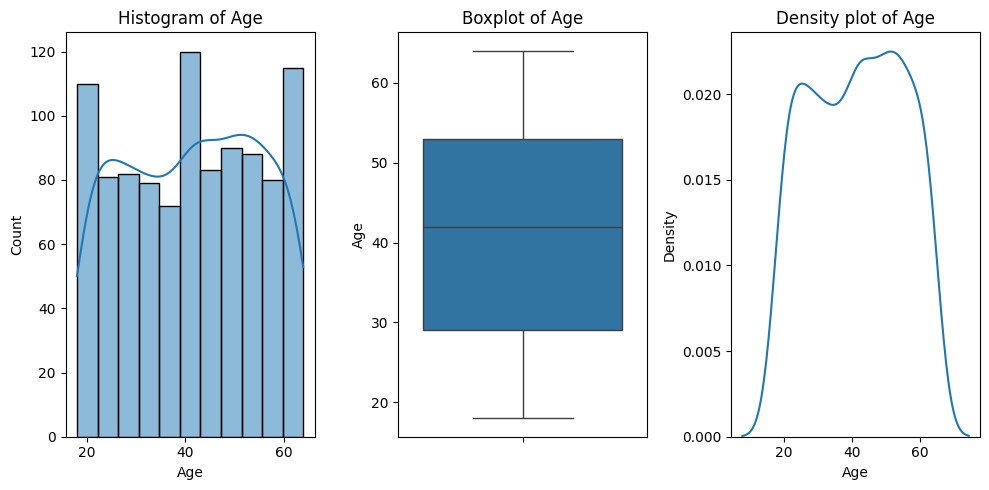

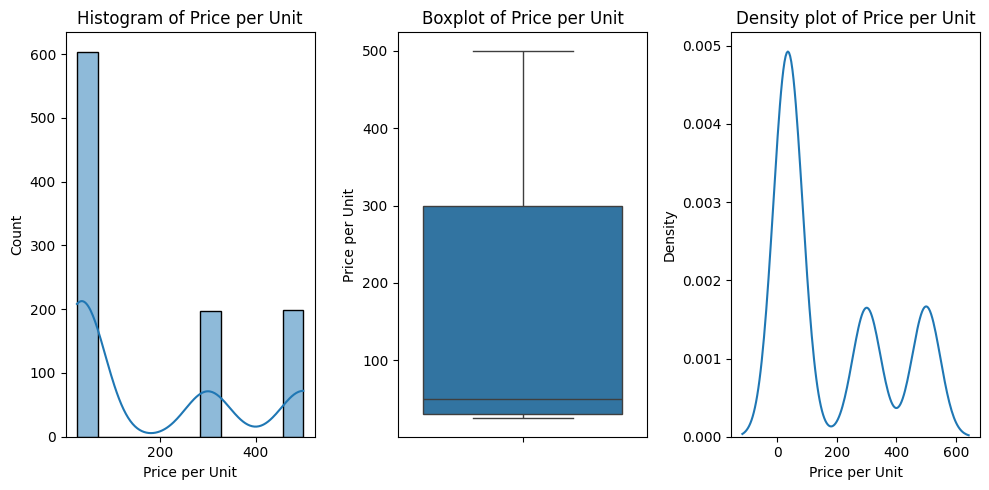

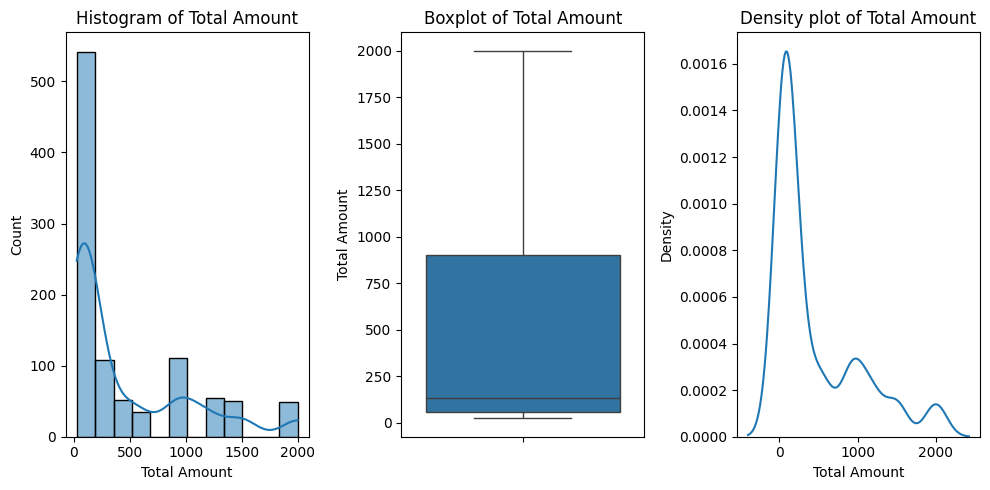

In [15]:
# Histogram, Boxplot, Density plot for numerical columns
import matplotlib.pyplot as plt
import seaborn as sns
for col in numeric_cols:
  plt.figure(figsize=(10,5))

  plt.subplot(1,3,1)
  sns.histplot(df[col], kde=True)
  plt.title(f'Histogram of {col}')

  plt.subplot(1,3,2)
  sns.boxplot(df[col])
  plt.title(f'Boxplot of {col}')

  plt.subplot(1,3,3)
  sns.kdeplot(df[col])
  plt.title(f'Density plot of {col}')

  plt.tight_layout()
  plt.show()


 Frequency counts for Gender:
 Gender
Female    510
Male      490
Name: count, dtype: int64


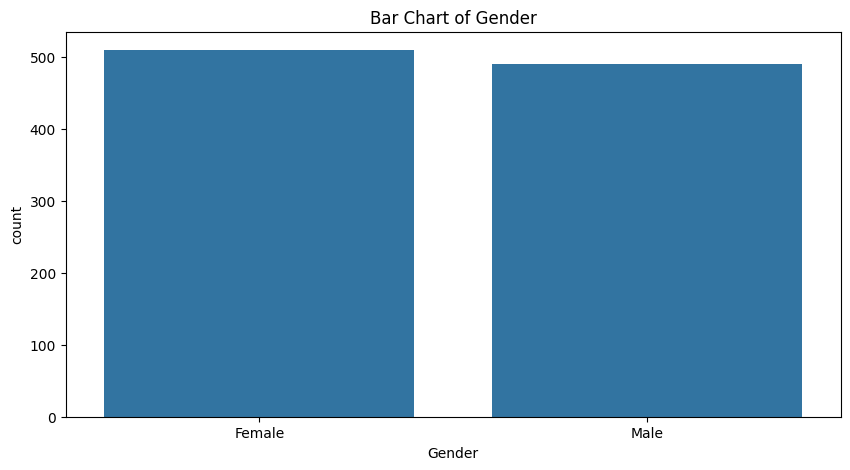


 Frequency counts for Product Category:
 Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


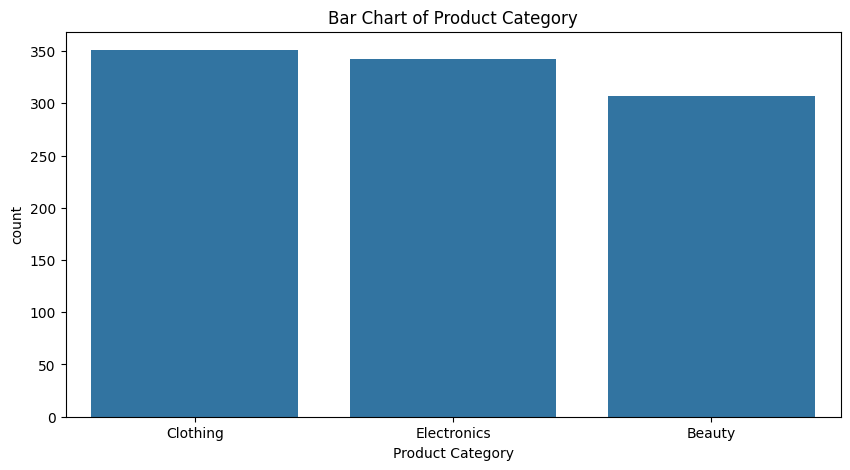

In [16]:
#Frequency count for categorical columns
cat_cols= ['Gender','Product Category']

for index, col in enumerate(cat_cols):
  print(f'\n Frequency counts for {col}:\n', df[col].value_counts())
  plt.figure(figsize=(10,5))
  sns.countplot(x=col, data=df, order=df[col].value_counts().index)
  plt.title(f'Bar Chart of {col}')
  plt.show()


 Date Range for Date: 2023-01-01 00:00:00 to 2024-01-01 00:00:00
Time Span: 365 days


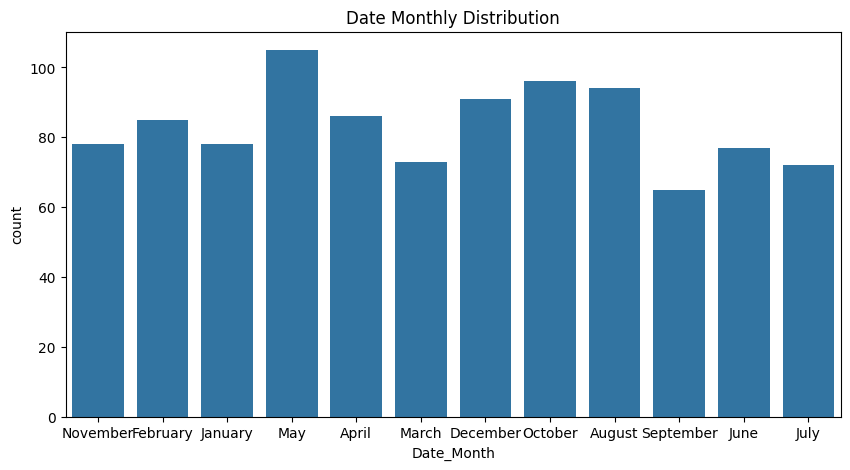

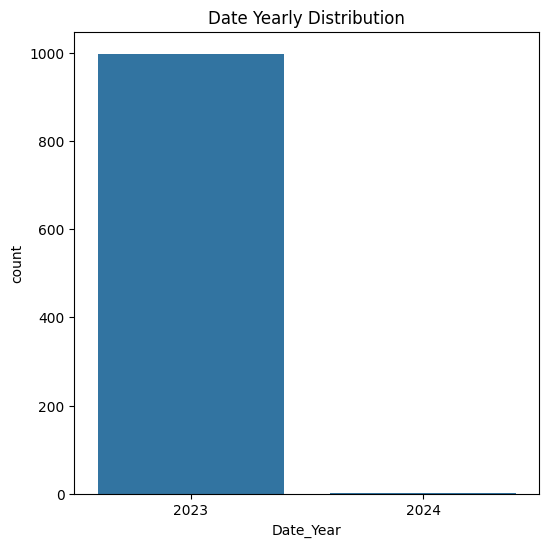

In [17]:
date_cols = ['Date']
for col in date_cols:
  print(f'\n Date Range for {col}: {df[col].min()} to {df[col].max()}')
  print(f'Time Span: {(df[col].max() - df[col].min()).days} days')

  # Monthly Distribution
  plt.figure(figsize=(10,5))
  df['Date_Month'] = df['Date'].dt.month_name()
  sns.countplot(x='Date_Month', data=df)
  plt.title('Date Monthly Distribution')
  plt.show()

  # Year Distribution
  plt.figure(figsize=(6,6))
  df['Date_Year'] = df['Date'].dt.year
  sns.countplot(x='Date_Year', data=df)
  plt.title('Date Yearly Distribution')
  plt.show()

In [18]:
def time_granularity(series):
  diffs = series.sort_values().diff().dropna().dt.days
  return diffs.describe()

In [19]:
time_granularity(df['Date'])

,Date
count,999.000000
mean,0.365365
std,0.523632
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,2.000000


In [20]:
df['Date'].sort_values().diff().value_counts()

,count
Date,
0 days,655
1 days,323
2 days,21


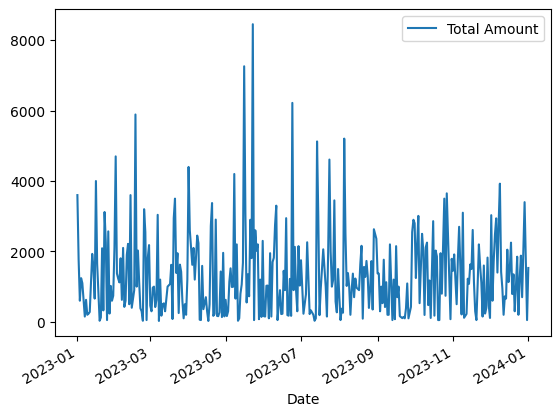

In [21]:
df.groupby('Date')[['Total Amount']].sum().plot()
plt.show()

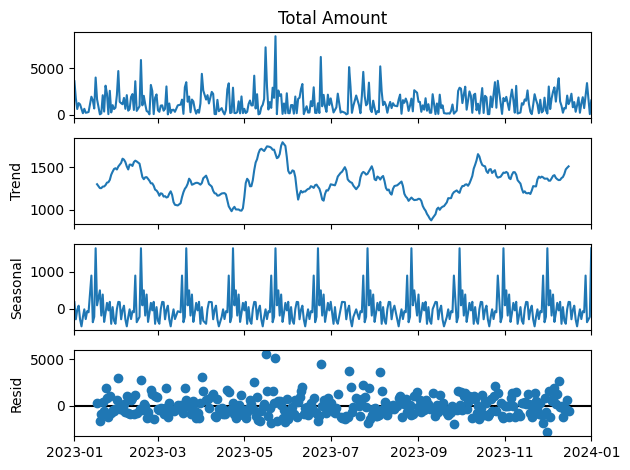

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_daily = df.groupby('Date')['Total Amount'].sum()
result = seasonal_decompose(df_daily, model='additive', period=30)
result.plot().show()

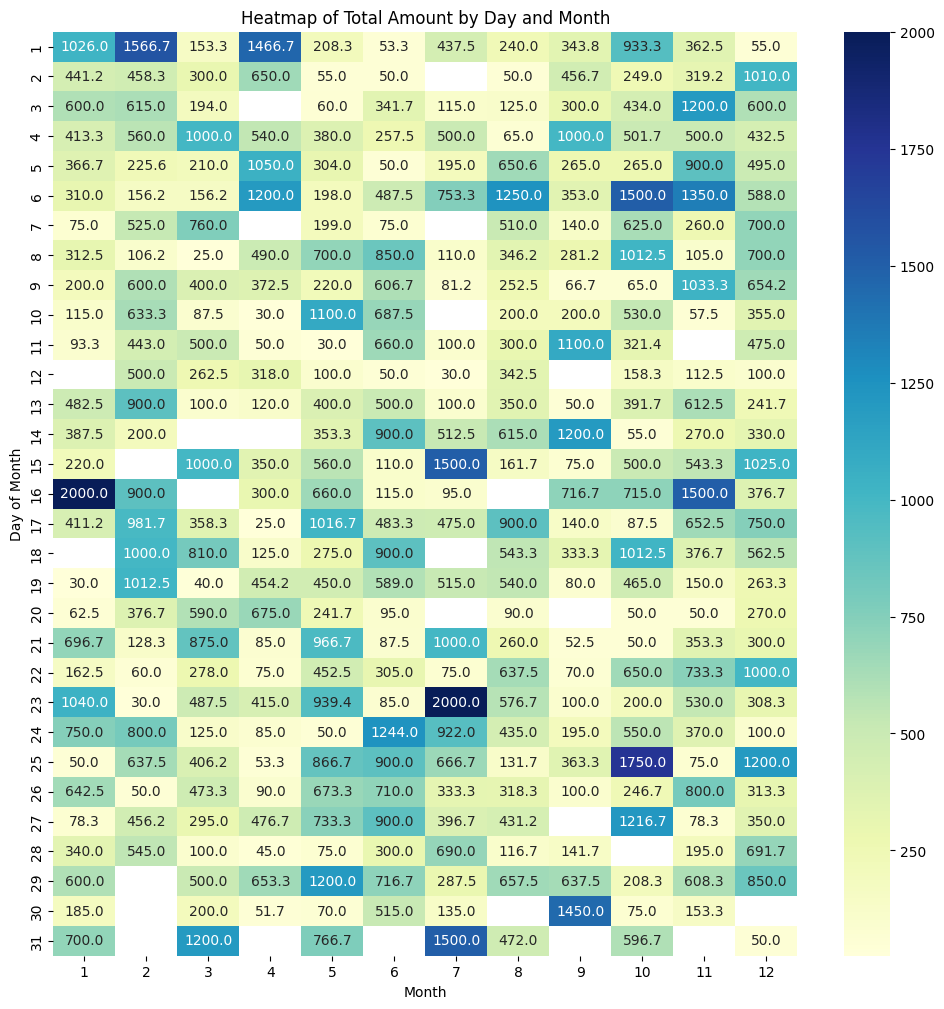

In [29]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
heatmap_data = df.pivot_table(index='Day', columns='Month', values='Total Amount', aggfunc='mean')

#Plot heatmap
plt.figure(figsize=(12,12))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.1f')
plt.xlabel('Month')
plt.ylabel('Day of Month')
plt.title('Heatmap of Total Amount by Day and Month')
plt.show()

# Bivariant Analysis

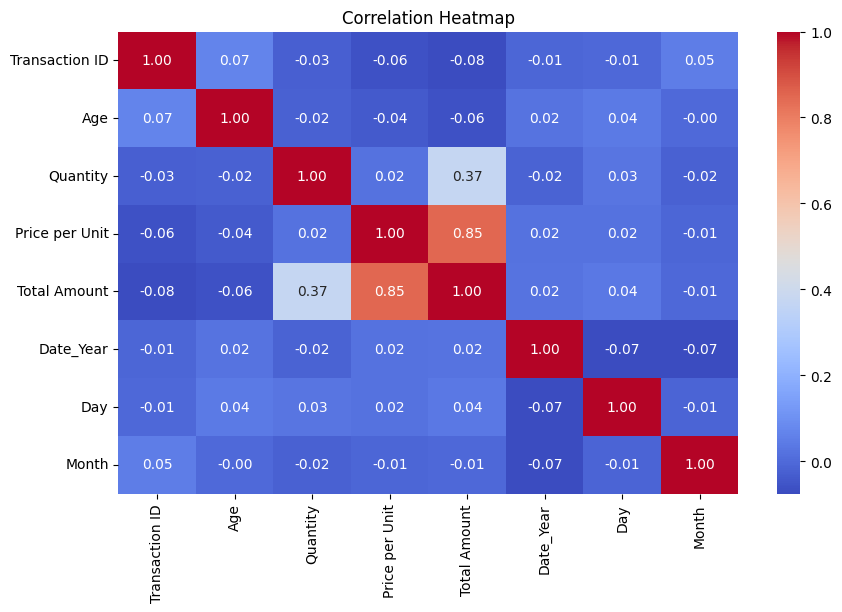

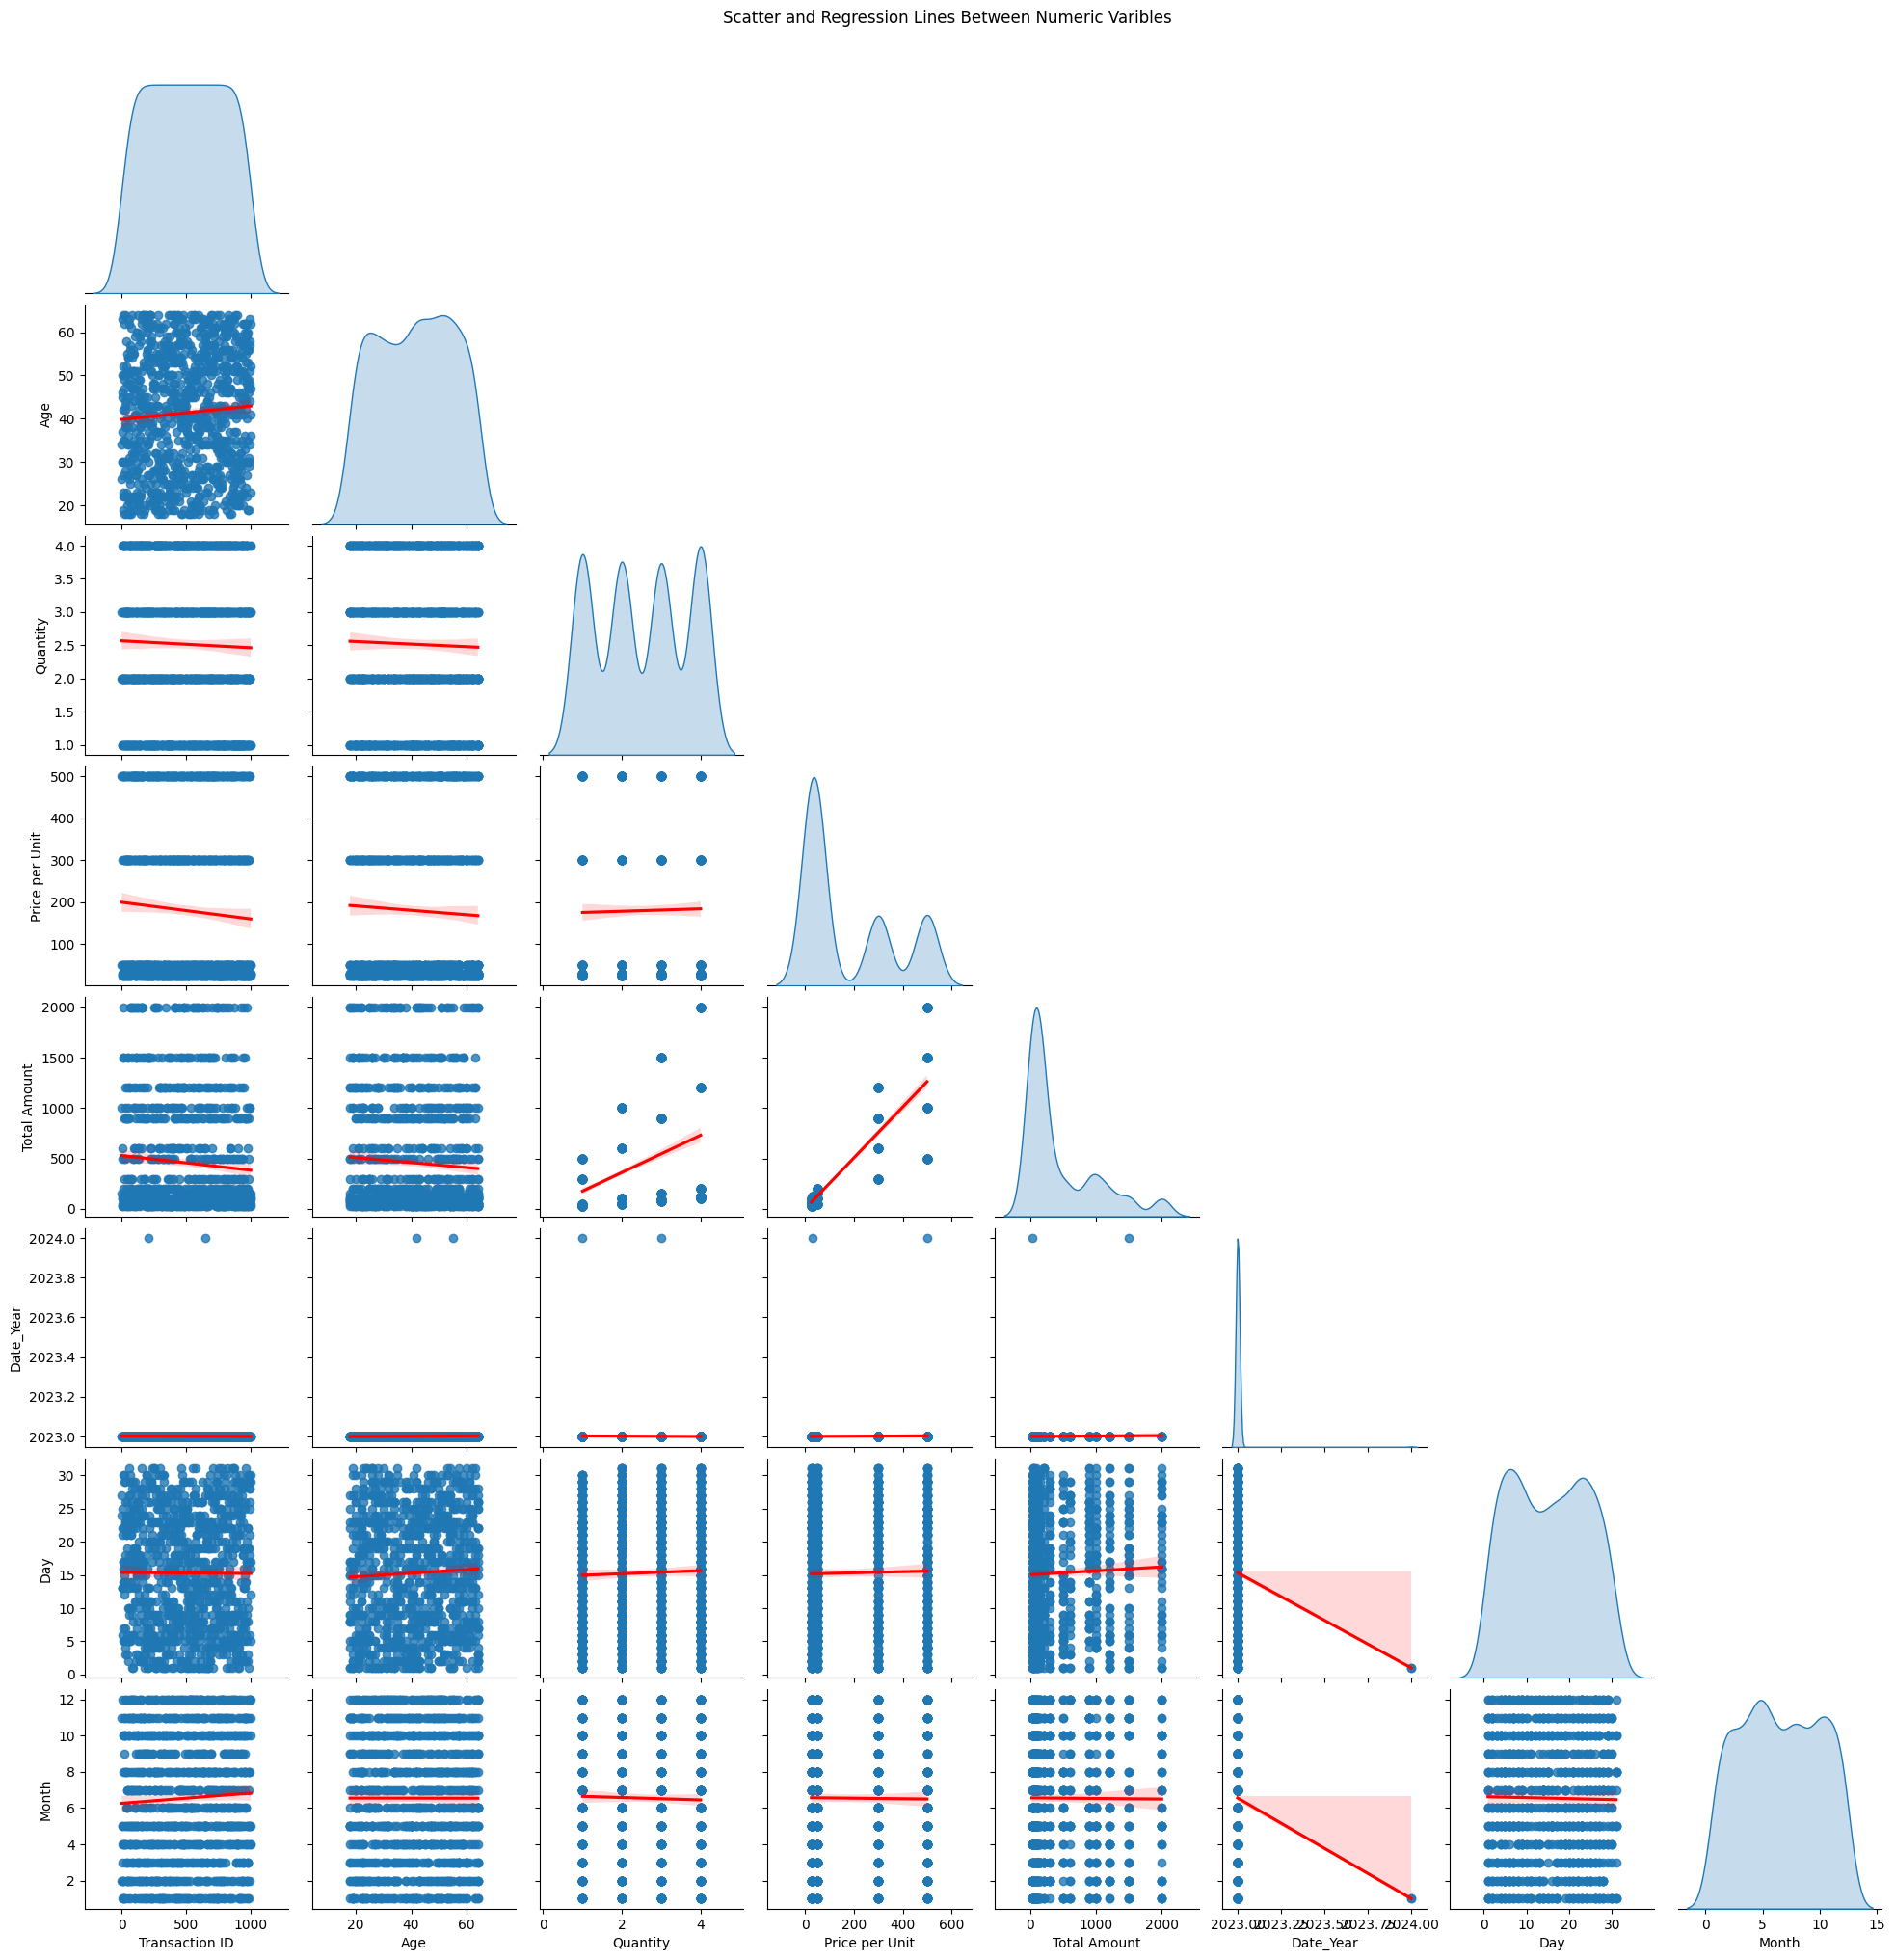

In [35]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Pairwise Scatter plots + regression line
sns.pairplot(df, kind='reg', diag_kind='kde', corner=True, plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Scatter and Regression Lines Between Numeric Varibles', y=1.02)
plt.show()

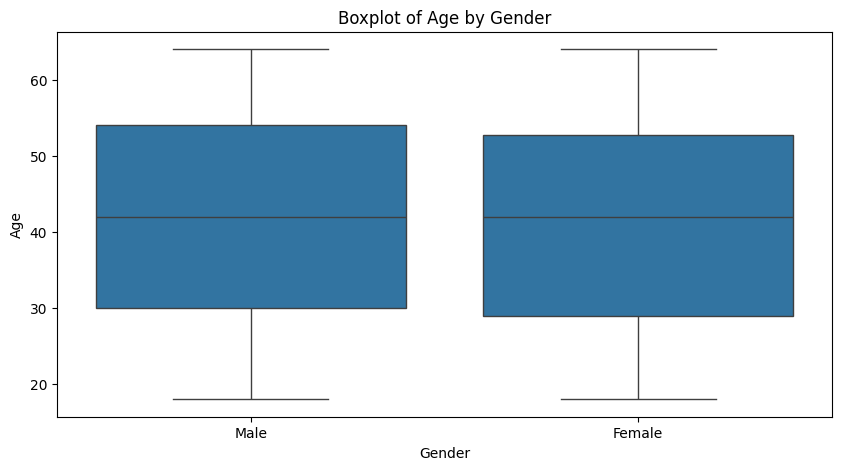


 Group Mean and Median of Age by Gender:
             mean  median  count
Gender                          
Female  41.356863    42.0    510
Male    41.428571    42.0    490


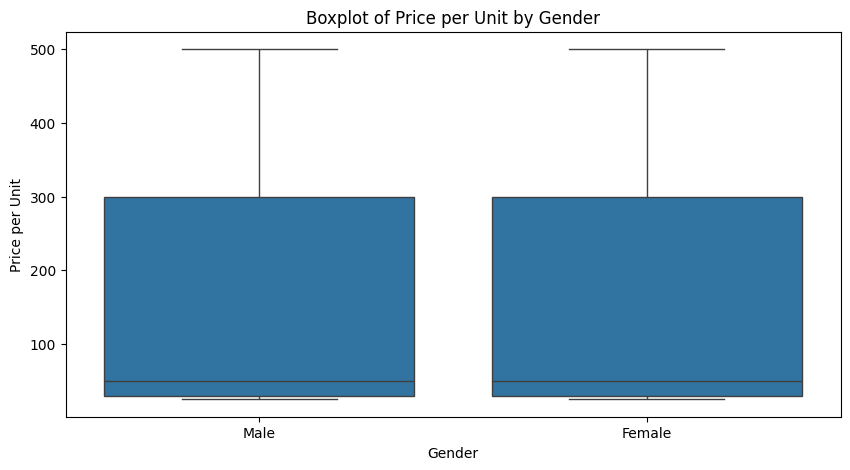


 Group Mean and Median of Price per Unit by Gender:
              mean  median  count
Gender                           
Female  180.068627    50.0    510
Male    179.704082    50.0    490


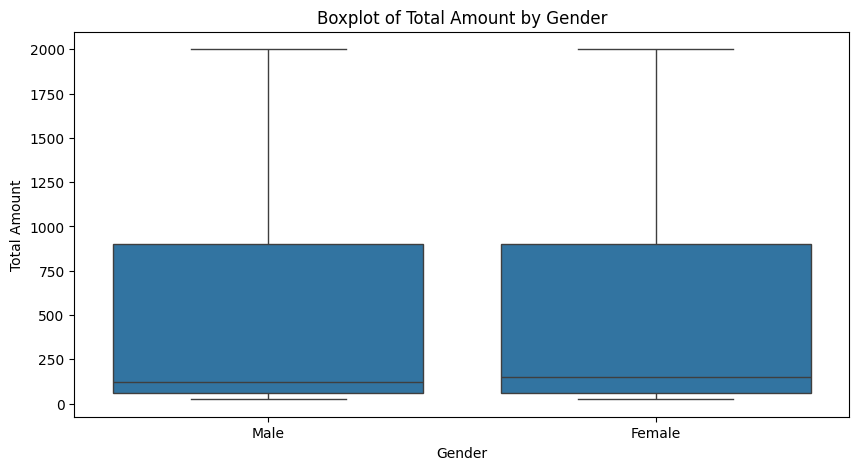


 Group Mean and Median of Total Amount by Gender:
              mean  median  count
Gender                           
Female  456.549020   150.0    510
Male    455.428571   120.0    490


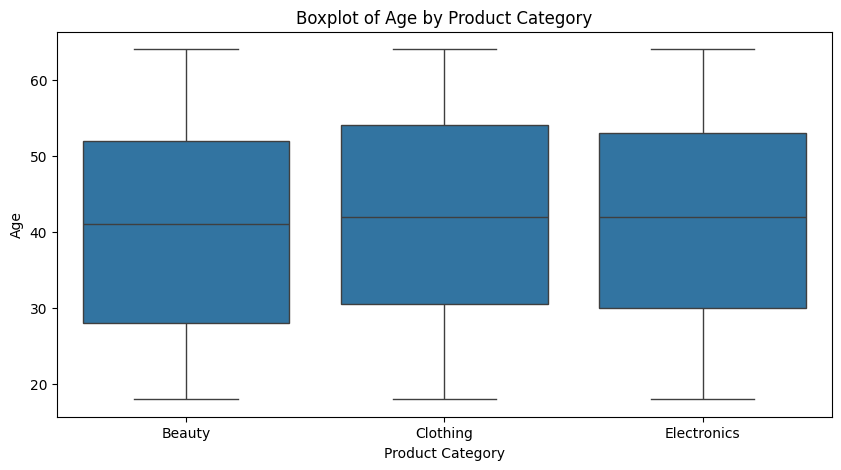


 Group Mean and Median of Age by Product Category:
                       mean  median  count
Product Category                          
Beauty            40.371336    41.0    307
Clothing          41.948718    42.0    351
Electronics       41.736842    42.0    342


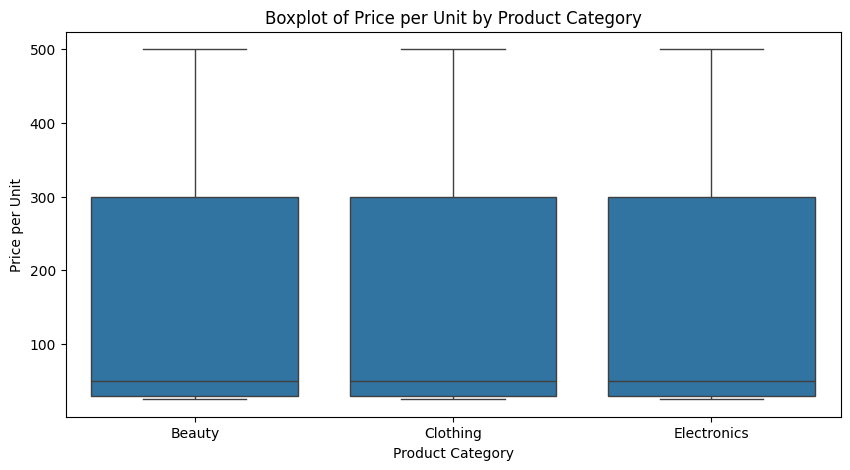


 Group Mean and Median of Price per Unit by Product Category:
                        mean  median  count
Product Category                           
Beauty            184.055375    50.0    307
Clothing          174.287749    50.0    351
Electronics       181.900585    50.0    342


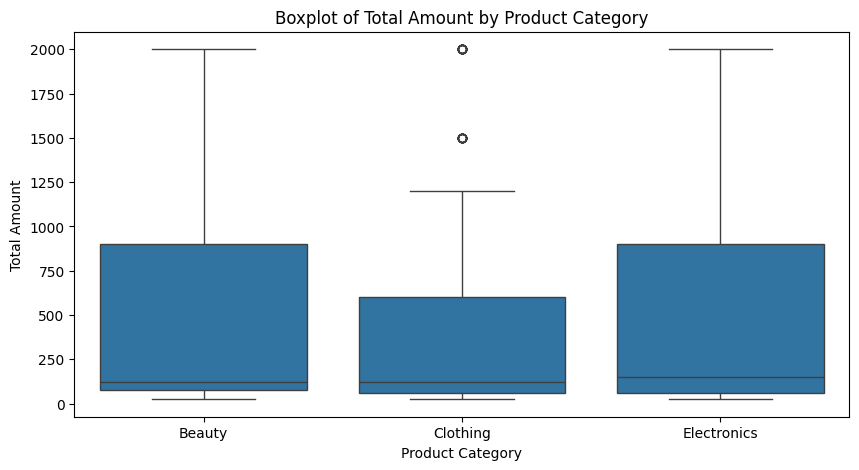


 Group Mean and Median of Total Amount by Product Category:
                        mean  median  count
Product Category                           
Beauty            467.475570   120.0    307
Clothing          443.247863   120.0    351
Electronics       458.786550   150.0    342


In [37]:
cat_col = ['Gender','Product Category']

for cat in cat_col:
  for num in numeric_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=cat, y=num, data=df)
    plt.title(f'Boxplot of {num} by {cat}')
    plt.show()

    print(f'\n Group Mean and Median of {num} by {cat}:')
    print(df.groupby(cat)[num].agg(['mean','median','count']))

In [38]:
clothing = df[df['Product Category'] == 'Clothing']['Total Amount']

Q1 = clothing.quantile(0.25)
Q3 = clothing.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = clothing[(clothing < lower) | (clothing > upper)]

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Upper limit:', upper)
print('Number of outliers:', len(outliers))
print(outliers.sort_values(ascending=False).head(10))

Q1: 60.0
Q3: 600.0
IQR: 540.0
Upper limit: 1410.0
Number of outliers: 32
165    2000
123    2000
268    2000
252    2000
419    2000
341    2000
730    2000
788    2000
663    2000
625    2000
Name: Total Amount, dtype: int64


In [45]:
from scipy import stats
anova_res = stats.f_oneway(*[group['Total Amount'].values for name, group in df.groupby('Product Category')])
print('ANOVA Test for Total Amount across Product Category:\n')
print('F-statistics', round(anova_res.statistic,3),', p-value:', round(anova_res.pvalue,3))

ANOVA Test for Total Amount across Product Category:

F-statistics 0.159 , p-value: 0.853



 Contingency Table (Gender vs Product Category):
 Product Category  Beauty  Clothing  Electronics
Gender                                         
Female               166       174          170
Male                 141       177          172


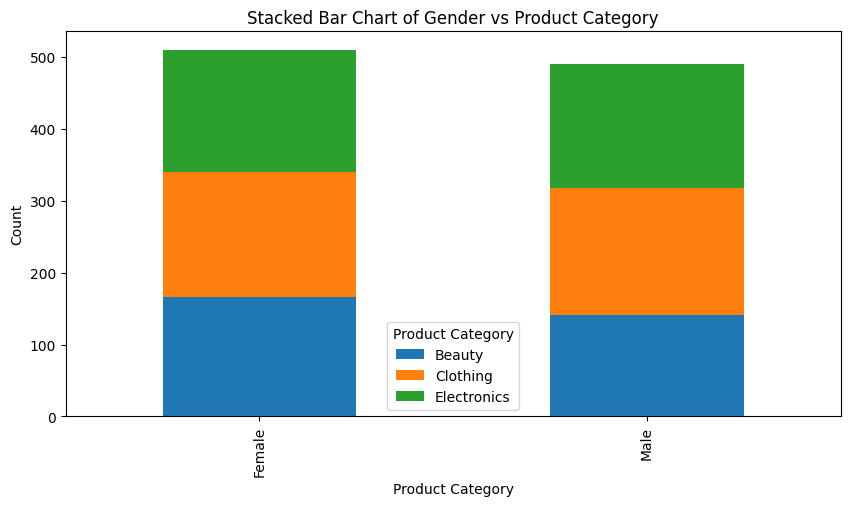


Chi-Square Test Results
Chi2=1.674, p-value = 0.433, Degrees of Freedom = 2
No significant relationship (fail to reject null hypothesis)


In [47]:
contingency = pd.crosstab(df['Gender'], df['Product Category'])
print('\n Contingency Table (Gender vs Product Category):\n', contingency)

#Stacked Bar Chart
contingency.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Stacked Bar Chart of Gender vs Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.show()

# Chi-Square Test of Independece
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print('\nChi-Square Test Results')
print(f'Chi2={chi2:.3f}, p-value = {p:.3f}, Degrees of Freedom = {dof}')

if p<0.05:
  print('Significant relationship (reject null hypothesis)')
else:
  print('No significant relationship (fail to reject null hypothesis)')

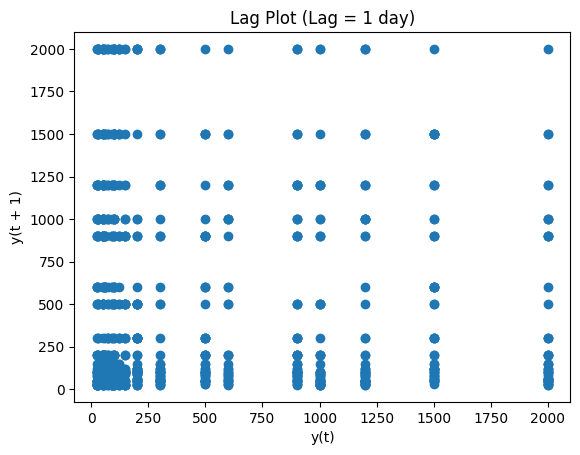

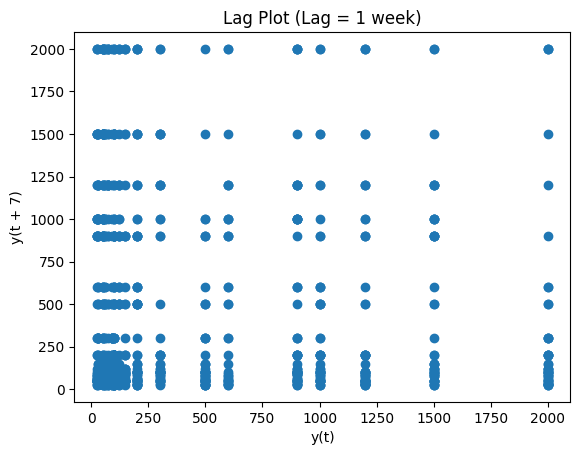

In [48]:
from pandas.plotting import lag_plot

plt.figure()
lag_plot(df['Total Amount'], lag=1)
plt.title('Lag Plot (Lag = 1 day)')
plt.show()

plt.figure()
lag_plot(df['Total Amount'], lag=7)
plt.title('Lag Plot (Lag = 1 week)')
plt.show()

<Figure size 640x480 with 0 Axes>

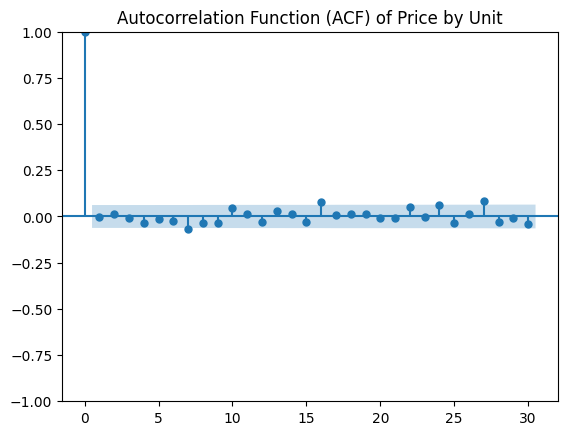

In [53]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure()
plot_acf(df['Price per Unit'], lags=30)
plt.title('Autocorrelation Function (ACF) of Price by Unit')
plt.show()

<Figure size 640x480 with 0 Axes>

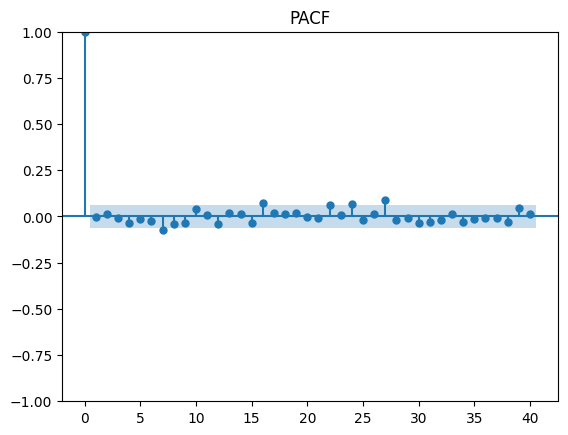

In [56]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure()
plot_pacf(df['Price per Unit'], lags=40, method='ywm')
plt.title('PACF')
plt.show()

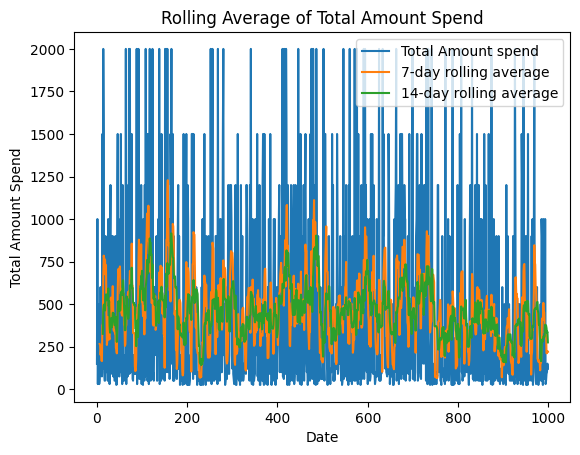

In [59]:
df['rolling_7'] = df['Total Amount'].rolling(window=7).mean()
df['rolling_14'] = df['Total Amount'].rolling(window=14).mean()

plt.figure()
plt.plot(df.index, df['Total Amount'], label='Total Amount spend')
plt.plot(df.index, df['rolling_7'], label='7-day rolling average')
plt.plot(df.index, df['rolling_14'], label='14-day rolling average')
plt.xlabel('Date')
plt.ylabel('Total Amount Spend')
plt.title('Rolling Average of Total Amount Spend')
plt.legend()
plt.show()

# Multivariant Analysis

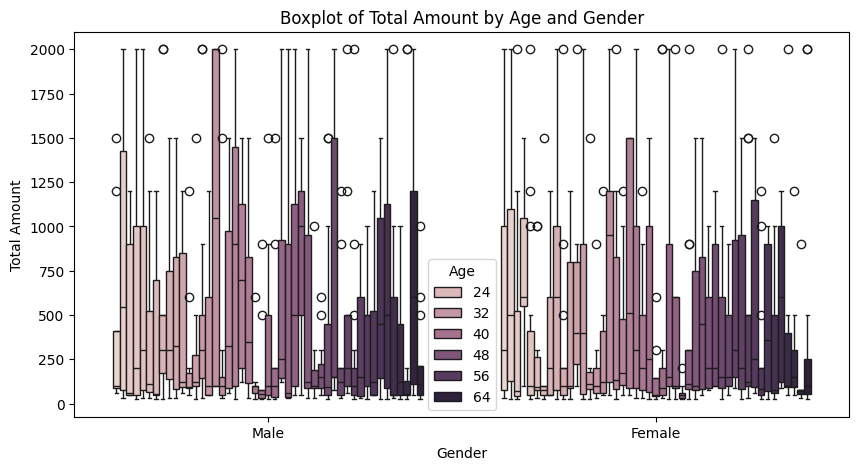

In [60]:
# Age + Gender = Total Amount
plt.figure(figsize=(10,5))
sns.boxplot(x='Gender', y='Total Amount', hue='Age', data=df, dodge=True)
plt.title('Boxplot of Total Amount by Age and Gender')
plt.show()

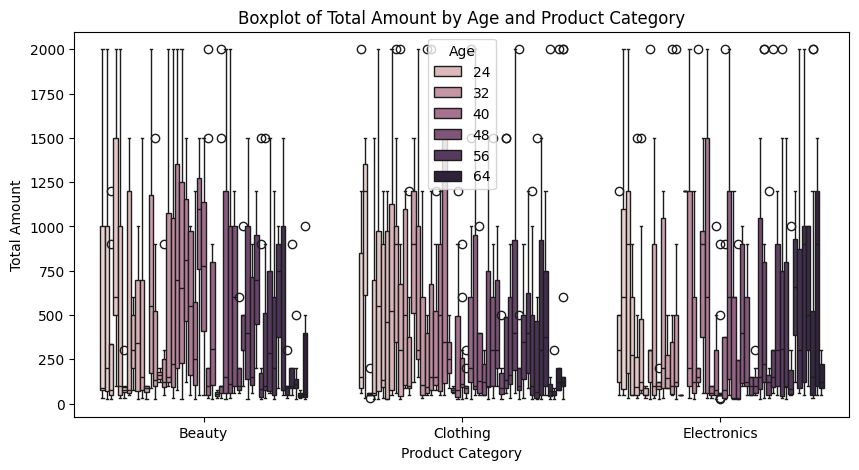

In [65]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Product Category', y='Total Amount', hue='Age', data=df, dodge=True)
plt.title('Boxplot of Total Amount by Age and Product Category')
plt.show()

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
X = df[numeric_cols]
#Standardize
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

#PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]
print('Explained Variance Ratio:', pca.explained_variance_ratio_)
print('Cumulative Explained Variance Ratio:', pca.explained_variance_ratio_.cumsum())

Explained Variance Ratio: [0.6192129  0.33152495]
Cumulative Explained Variance Ratio: [0.6192129  0.95073785]


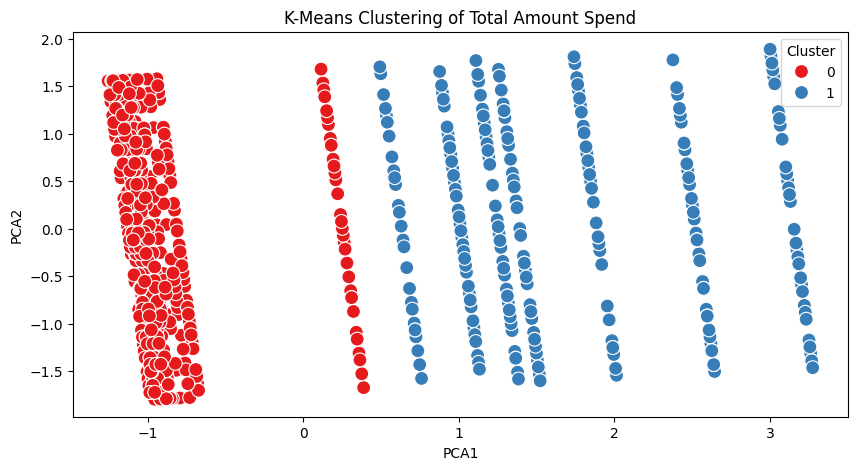

In [67]:
#K-Means clustering
kmeans = KMeans(n_clusters=2,random_state=42)
df['Cluster'] = kmeans.fit_predict(X_pca)
plt.figure(figsize=(10,5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1', s=100)
plt.title('K-Means Clustering of Total Amount Spend')
plt.show()

In [68]:
df['Cluster'].value_counts()

,count
Cluster,
0,650
1,350


In [69]:
print(df.groupby('Cluster')[numeric_cols].mean())

               Age  Price per Unit  Total Amount
Cluster                                         
0        41.861538       53.984615    102.923077
1        40.520000      413.714286   1111.714286
